# Semantic Consistency Radar Analysis

This notebook loads the semantic-consistency metrics table and produces two radar-chart views:
1. **Metric-wise radar**: one radar per metric, comparing models across evaluation methods.
2. **Model-wise radar**: one radar per model, comparing methods across metrics.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# Source table from thesis section 6.9.2.7
rows = [
    ('EEG embed', 'CLIP-like', 'GLIM [Liu et al, 2025]', 0.4269, 0.3245, 0.5714, 0.9348),
    ('EEG embed', 'CLIP-like', 'GRAPE-GLIM v1 (ours)', 0.2854, 0.1367, 0.3653, 0.4121),
    ('EEG embed', 'CLIP-like', 'GRAPE-GLIM v2 (ours)', 0.3237, 0.1531, 0.3480, 0.5711),

    ('Gen text', 'LLM-assist', 'GLIM [Liu et al, 2025]', 0.3957, 0.0724, 0.5633, 0.9216),
    ('Gen text', 'LLM-assist', 'GRAPE-GLIM v1 (ours)', 0.3094, 0.0776, 0.7286, 0.9121),
    ('Gen text', 'LLM-assist', 'GRAPE-GLIM v2 (ours)', 0.3165, 0.0796, 0.6459, 0.9189),

    ('Gen text embed', 'CLIP-like', 'GLIM [Liu et al, 2025]', 0.3957, 0.2071, 0.4326, 0.8736),
    ('Gen text embed', 'CLIP-like', 'GRAPE-GLIM v1 (ours)', 0.2878, 0.3020, 0.4827, 0.3909),
    ('Gen text embed', 'CLIP-like', 'GRAPE-GLIM v2 (ours)', 0.3909, 0.3643, 0.4827, 0.6150),

    ('Raw text', 'LLM-assist', 'GLIM [Liu et al, 2025]', 0.7338, 0.0969, 0.7551, 0.8614),
    ('Raw text', 'LLM-assist', 'GRAPE-GLIM v1 (ours)', 0.7337, 0.0745, 0.7551, 0.8641),
    ('Raw text', 'LLM-assist', 'GRAPE-GLIM v2 (ours)', 0.7337, 0.0765, 0.7704, 0.8641),

    ('Raw text embed', 'CLIP-like', 'GLIM [Liu et al, 2025]', 0.4556, 0.2530, 0.4969, 0.9185),
    ('Raw text embed', 'CLIP-like', 'GRAPE-GLIM v1 (ours)', 0.4197, 0.3786, 0.3786, 0.5072),
    ('Raw text embed', 'CLIP-like', 'GRAPE-GLIM v2 (ours)', 0.4101, 0.2959, 0.4827, 0.5408),
]

columns = [
    'Output', 'Method', 'Model',
    'ACC-1 Sentiment', 'ACC-1 Relation', 'ACC-3 Relation', 'ACC Corpus'
]

df = pd.DataFrame(rows, columns=columns)
df['Output-Method'] = df['Output'] + ' | ' + df['Method']
df

,Output,Method,Model,ACC-1 Sentiment,ACC-1 Relation,ACC-3 Relation,ACC Corpus,Output-Method
0,EEG embed,CLIP-like,"GLIM [Liu et al, 2025]",0.4269,0.3245,0.5714,0.9348,EEG embed | CLIP-like
1,EEG embed,CLIP-like,GRAPE-GLIM v1 (ours),0.2854,0.1367,0.3653,0.4121,EEG embed | CLIP-like
2,EEG embed,CLIP-like,GRAPE-GLIM v2 (ours),0.3237,0.1531,0.3480,0.5711,EEG embed | CLIP-like
3,Gen text,LLM-assist,"GLIM [Liu et al, 2025]",0.3957,0.0724,0.5633,0.9216,Gen text | LLM-assist
4,Gen text,LLM-assist,GRAPE-GLIM v1 (ours),0.3094,0.0776,0.7286,0.9121,Gen text | LLM-assist
5,Gen text,LLM-assist,GRAPE-GLIM v2 (ours),0.3165,0.0796,0.6459,0.9189,Gen text | LLM-assist
6,Gen text embed,CLIP-like,"GLIM [Liu et al, 2025]",0.3957,0.2071,0.4326,0.8736,Gen text embed | CLIP-like
7,Gen text embed,CLIP-like,GRAPE-GLIM v1 (ours),0.2878,0.3020,0.4827,0.3909,Gen text embed | CLIP-like
8,Gen text embed,CLIP-like,GRAPE-GLIM v2 (ours),0.3909,0.3643,0.4827,0.6150,Gen text embed | CLIP-like
9,Raw text,LLM-assist,"GLIM [Liu et al, 2025]",0.7338,0.0969,0.7551,0.8614,Raw text | LLM-assist


In [5]:
def _radar_angles(n):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    return angles

def _close(values):
    vals = list(values)
    vals += vals[:1]
    return vals

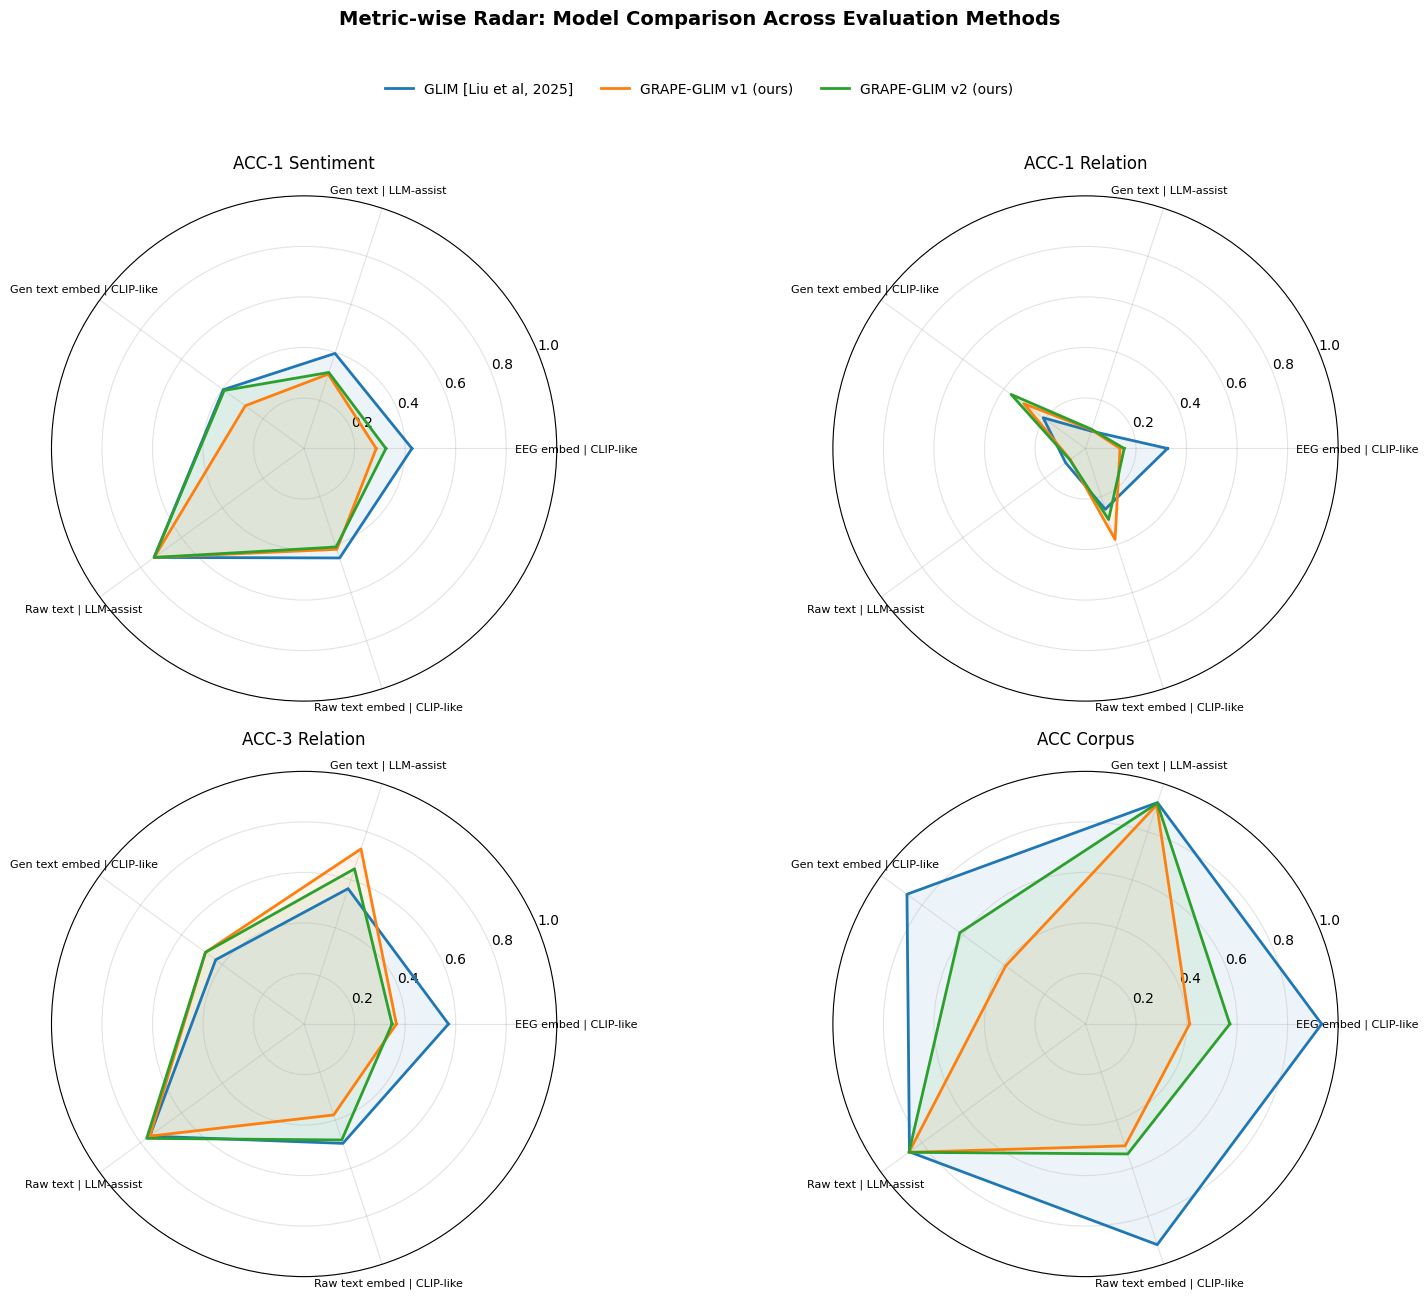

In [5]:
# Metric-wise radar charts: one radar per metric, lines = models, axes = output-method combinations
metrics = ['ACC-1 Sentiment', 'ACC-1 Relation', 'ACC-3 Relation', 'ACC Corpus']
combos = df['Output-Method'].drop_duplicates().tolist()
models = df['Model'].drop_duplicates().tolist()
angles = _radar_angles(len(combos))

fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for model in models:
        subset = df[df['Model'] == model].set_index('Output-Method')
        values = [subset.loc[c, metric] for c in combos]
        values = _close(values)
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(combos, fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=12, pad=20)
    ax.grid(alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Metric-wise Radar: Model Comparison Across Evaluation Methods', y=1.08, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

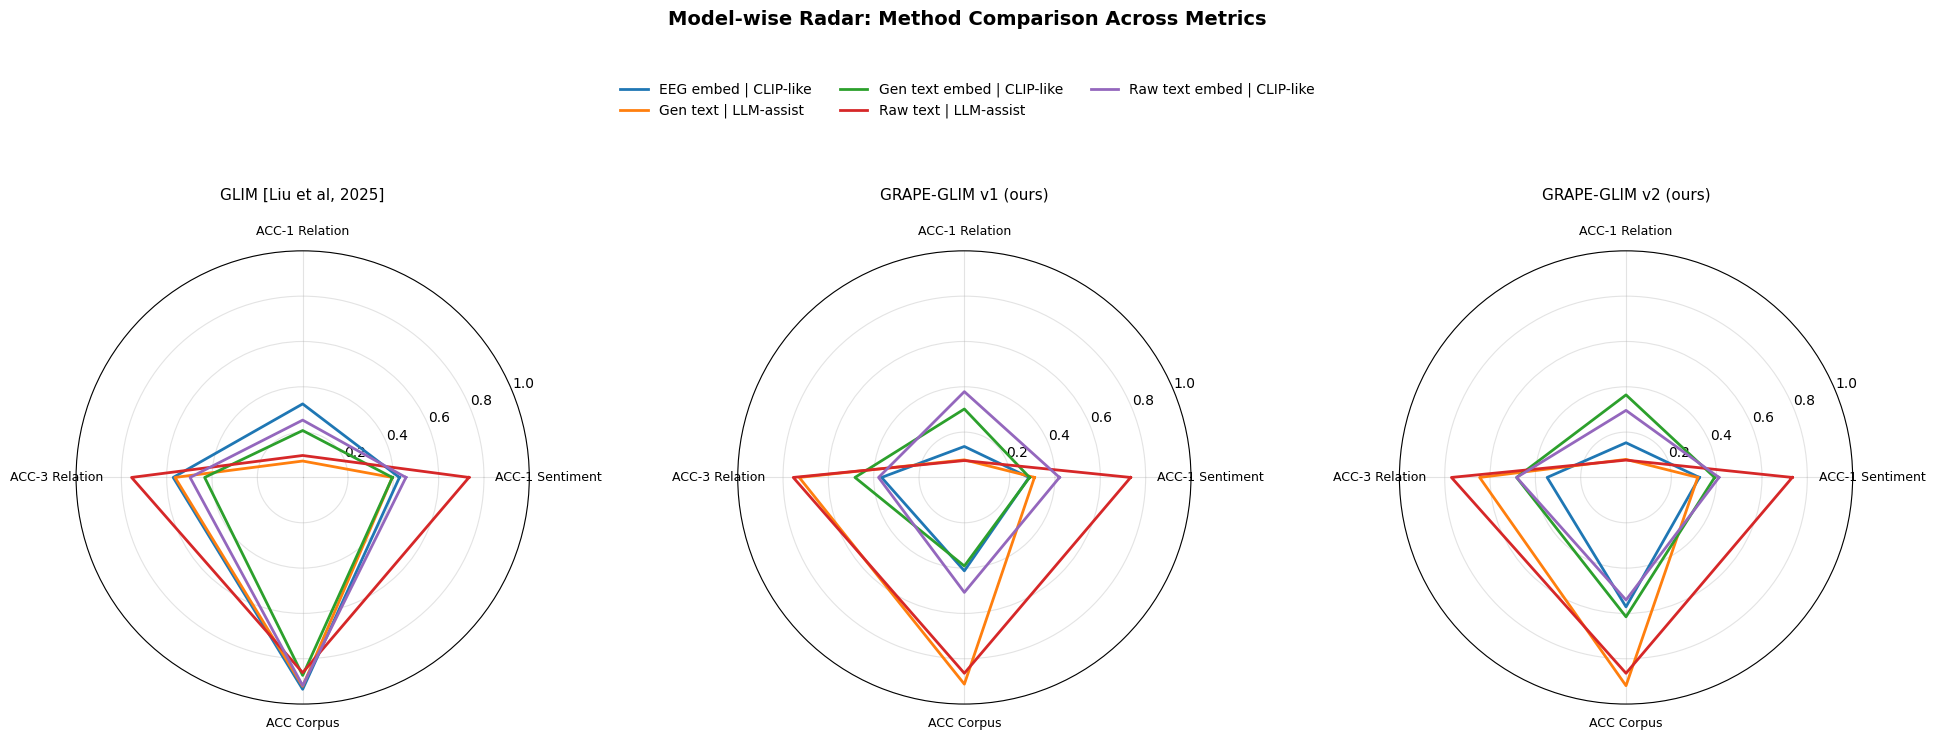

In [6]:
# Model-wise radar charts: one radar per model, lines = output-method combinations, axes = metrics
angles_m = _radar_angles(len(metrics))
combos = df['Output-Method'].drop_duplicates().tolist()
models = df['Model'].drop_duplicates().tolist()

fig, axes = plt.subplots(1, len(models), figsize=(20, 6), subplot_kw=dict(polar=True))
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    subset_model = df[df['Model'] == model].set_index('Output-Method')
    for combo in combos:
        vals = [subset_model.loc[combo, m] for m in metrics]
        vals = _close(vals)
        ax.plot(angles_m, vals, linewidth=2, label=combo)

    ax.set_xticks(angles_m[:-1])
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(model, fontsize=11, pad=18)
    ax.grid(alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.12))
fig.suptitle('Model-wise Radar: Method Comparison Across Metrics', y=1.22, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# save source table as CSV next to this notebook
out_dir = Path.cwd()
csv_path = out_dir / 'semantic_consistency_metrics.csv'
df.to_csv(csv_path, index=False)
print(f'Saved metrics table to: {csv_path}')

Saved metrics table to: e:\MSc Files\MSc Project\gated-glim\GLIM\results\eeg-to-text\sementic-consistency\semantic_consistency_metrics.csv


In [6]:
# --- Output-Method-wise summary table ---
# Assumes df already exists from your earlier cell.

metrics = ['ACC-1 Sentiment', 'ACC-1 Relation', 'ACC-3 Relation', 'ACC Corpus']

df_plot = df.copy()
df_plot['Output-Method'] = df_plot['Output'] + ' | ' + df_plot['Method']

# Mean across the 4 metrics for each row (Model x Output-Method)
df_plot['MeanScore'] = df_plot[metrics].mean(axis=1)

summary = (
    df_plot
    .pivot_table(index='Output-Method', columns='Model', values='MeanScore', aggfunc='mean')
    .sort_index()
)

summary

Model,"GLIM [Liu et al, 2025]",GRAPE-GLIM v1 (ours),GRAPE-GLIM v2 (ours)
Output-Method,,,
EEG embed | CLIP-like,0.56440,0.299875,0.348975
Gen text embed | CLIP-like,0.47725,0.365850,0.463225
Gen text | LLM-assist,0.48825,0.506925,0.490225
Raw text embed | CLIP-like,0.53100,0.421025,0.432375
Raw text | LLM-assist,0.61180,0.606850,0.611175


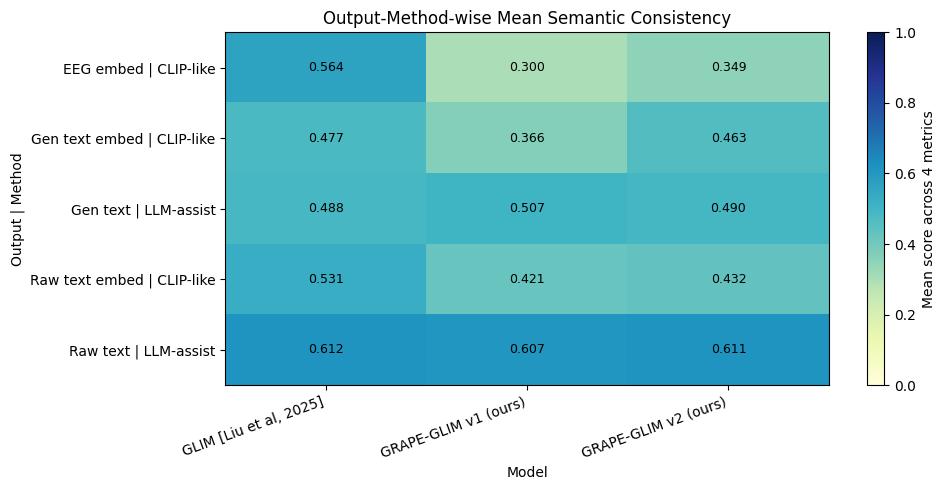

In [9]:
# --- Heatmap-style view (matplotlib only) ---
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(summary.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)

ax.set_title('Output-Method-wise Mean Semantic Consistency')
ax.set_xlabel('Model')
ax.set_ylabel('Output | Method')
ax.set_xticks(np.arange(summary.shape[1]))
ax.set_xticklabels(summary.columns, rotation=20, ha='right')
ax.set_yticks(np.arange(summary.shape[0]))
ax.set_yticklabels(summary.index)

# Annotate cells
for i in range(summary.shape[0]):
    for j in range(summary.shape[1]):
        val = summary.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color='black')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mean score across 4 metrics')

plt.tight_layout()
plt.show()

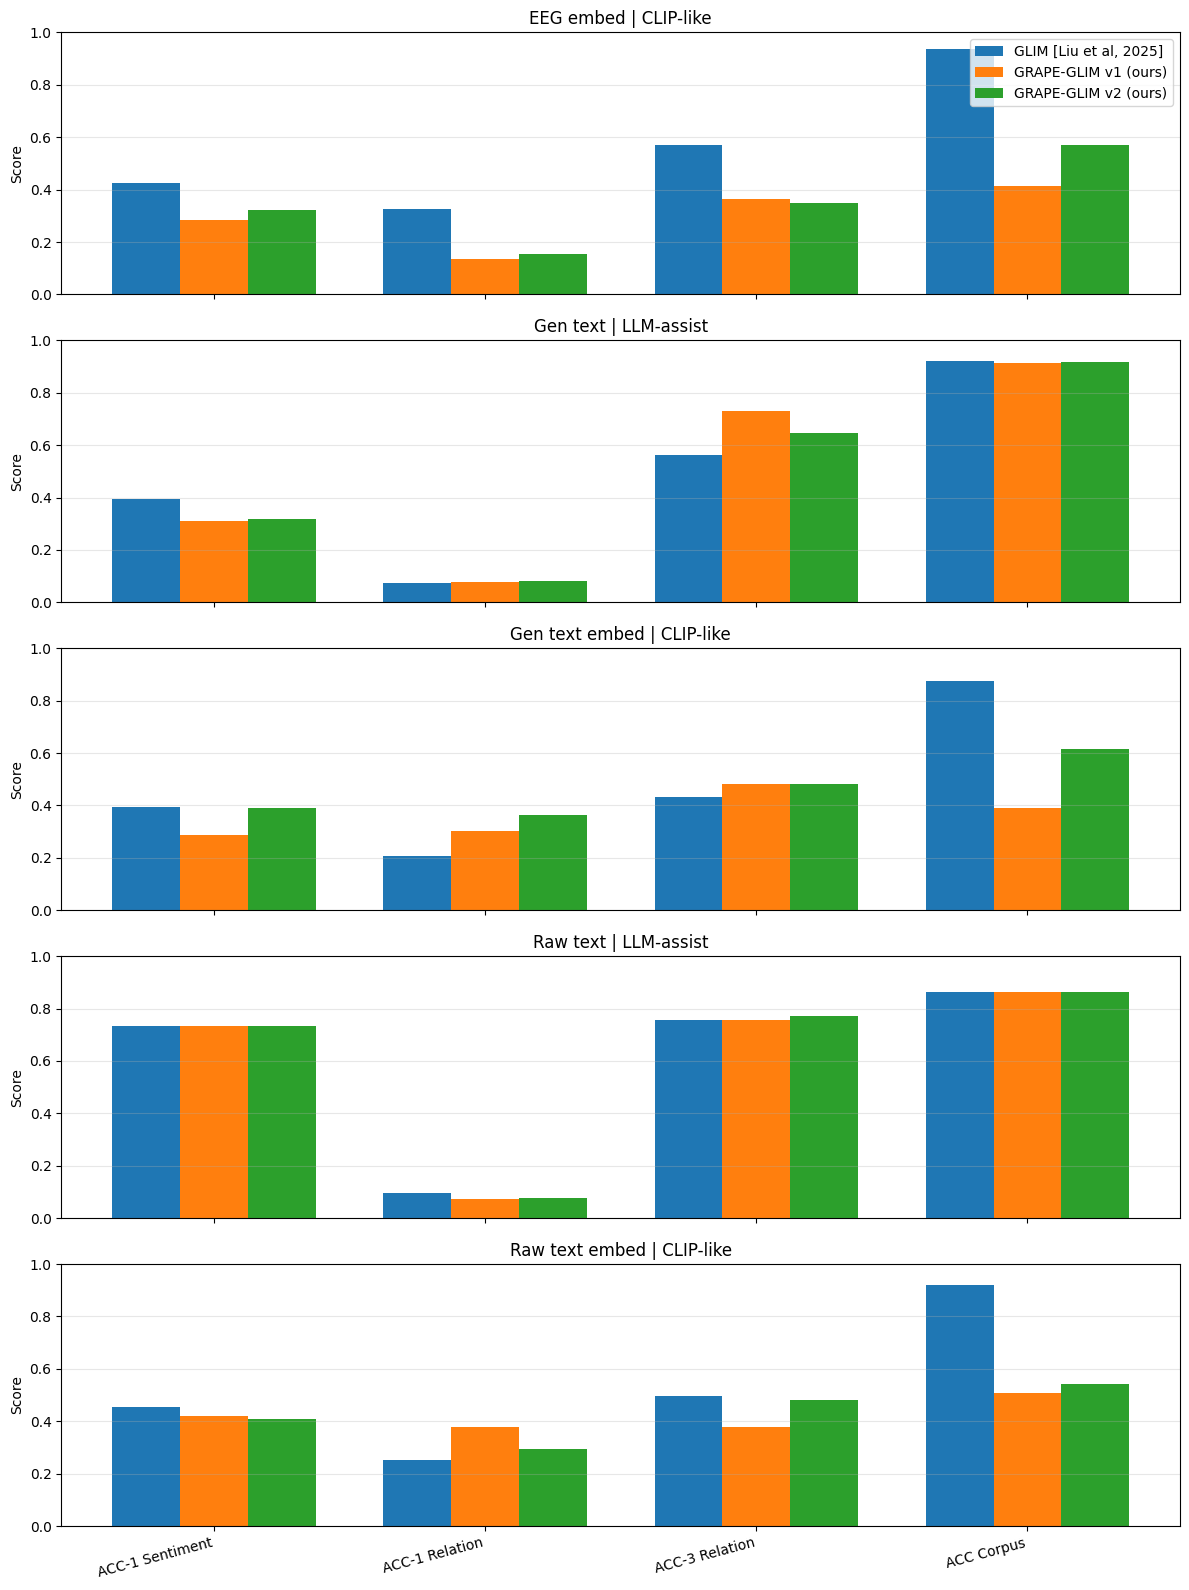

In [10]:
# --- Per Output-Method, per-metric bars (compare models) ---
import matplotlib.pyplot as plt
import numpy as np

output_methods = df_plot['Output-Method'].drop_duplicates().tolist()
models = df_plot['Model'].drop_duplicates().tolist()

fig, axes = plt.subplots(len(output_methods), 1, figsize=(12, 3.2 * len(output_methods)), sharex=True)
if len(output_methods) == 1:
    axes = [axes]

x = np.arange(len(metrics))
bar_w = 0.25

for ax, om in zip(axes, output_methods):
    sub = df_plot[df_plot['Output-Method'] == om].set_index('Model')

    for k, model in enumerate(models):
        vals = [sub.loc[model, m] for m in metrics]
        ax.bar(x + (k - 1) * bar_w, vals, width=bar_w, label=model)

    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score')
    ax.set_title(f'{om}')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(metrics, rotation=15, ha='right')
axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def radar_angles(n):
    a = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    return a + a[:1]

def close_loop(vals):
    vals = list(vals)
    return vals + vals[:1]

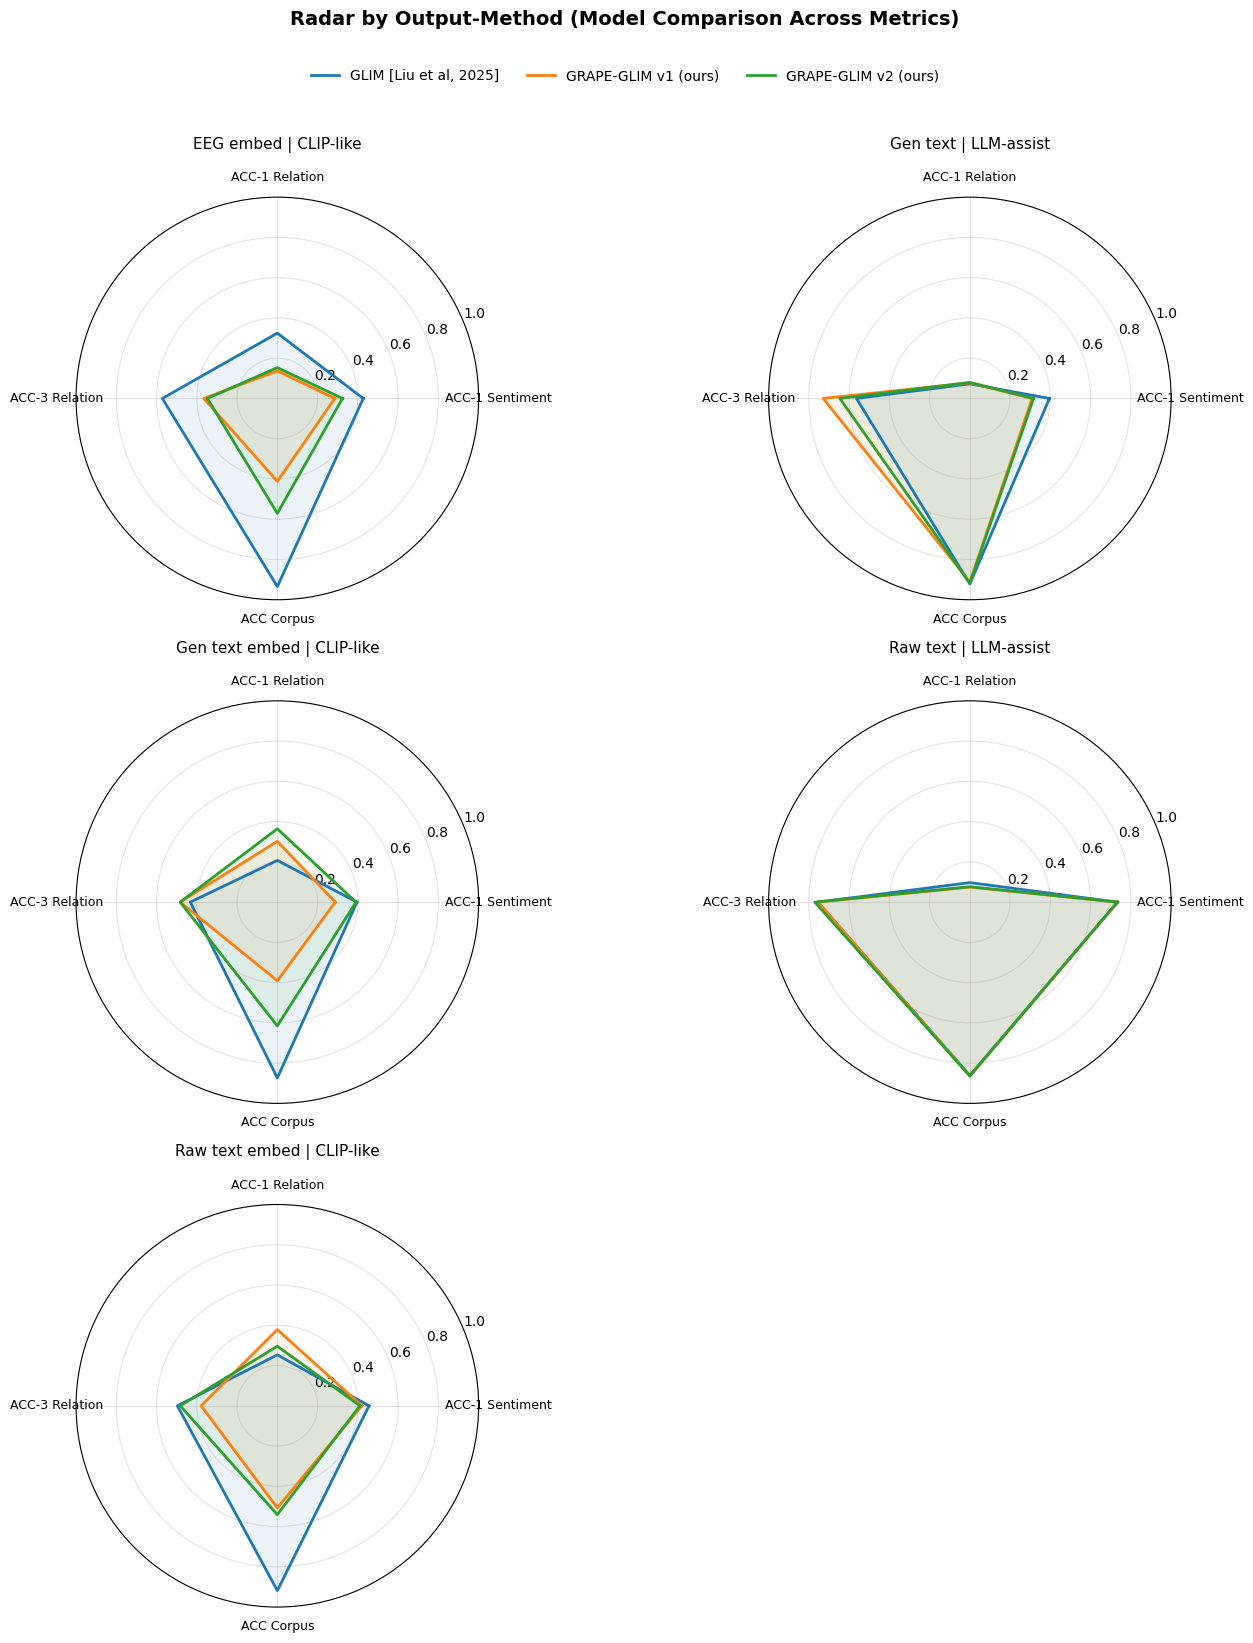

In [8]:
metrics = ['ACC-1 Sentiment', 'ACC-1 Relation', 'ACC-3 Relation', 'ACC Corpus']

df_plot = df.copy()
df_plot['Output-Method'] = df_plot['Output'] + ' | ' + df_plot['Method']

output_methods = df_plot['Output-Method'].drop_duplicates().tolist()
models = df_plot['Model'].drop_duplicates().tolist()

angles = radar_angles(len(metrics))

n = len(output_methods)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.2 * nrows), subplot_kw=dict(polar=True))
axes = np.array(axes).reshape(-1)

for ax, om in zip(axes, output_methods):
    sub = df_plot[df_plot['Output-Method'] == om].set_index('Model')
    for model in models:
        vals = [sub.loc[model, m] for m in metrics]
        vals = close_loop(vals)
        ax.plot(angles, vals, linewidth=2, label=model)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(om, fontsize=11, pad=16)
    ax.grid(alpha=0.35)

for ax in axes[len(output_methods):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Radar by Output-Method (Model Comparison Across Metrics)', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

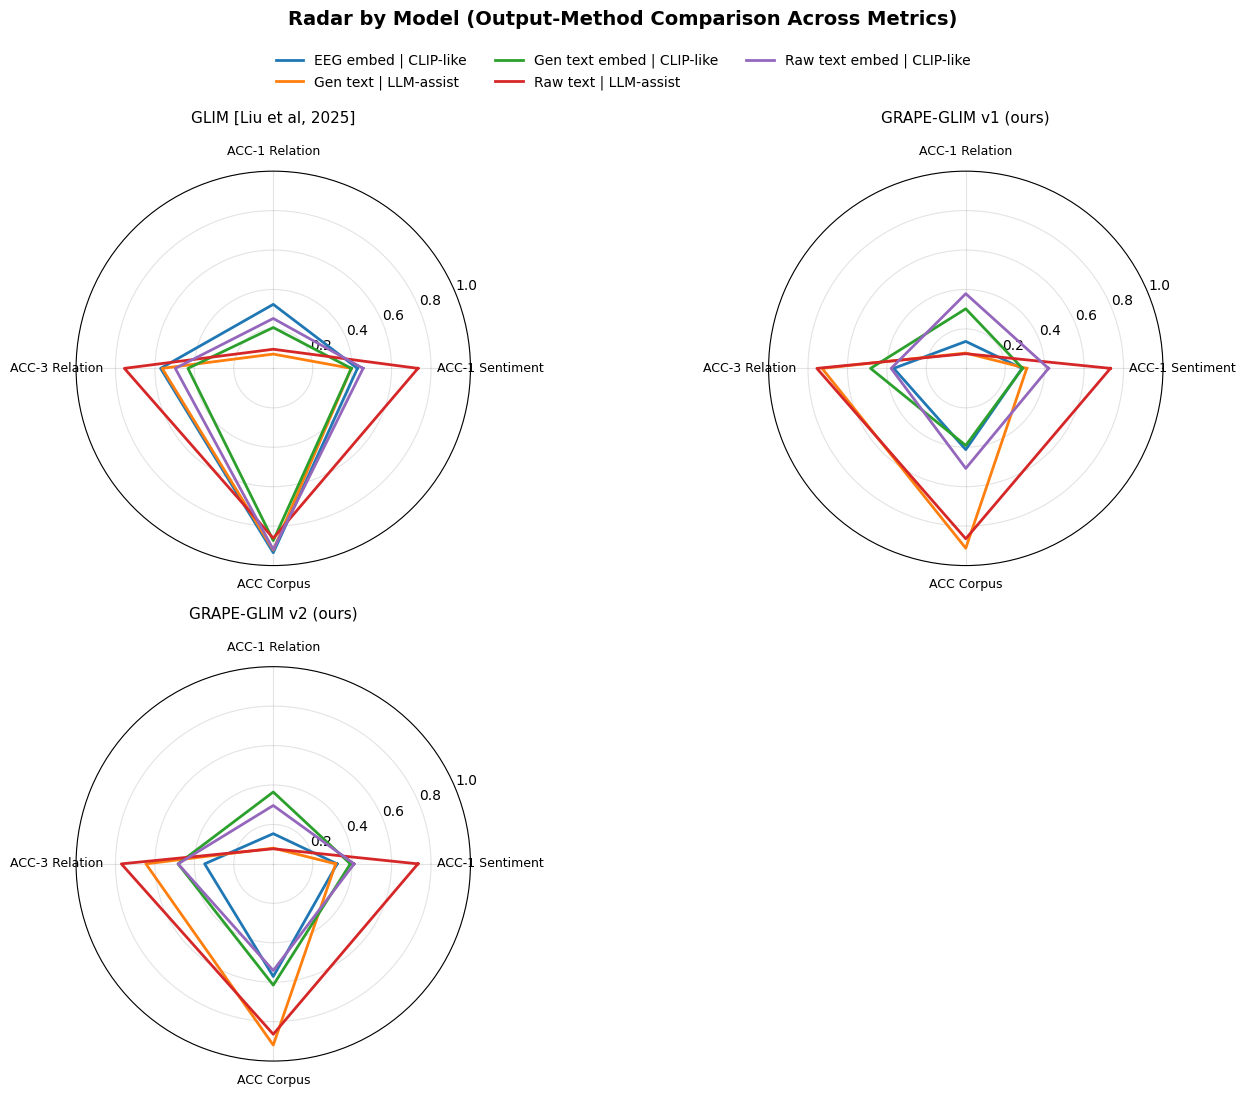

In [9]:
metrics = ['ACC-1 Sentiment', 'ACC-1 Relation', 'ACC-3 Relation', 'ACC Corpus']

df_plot = df.copy()
df_plot['Output-Method'] = df_plot['Output'] + ' | ' + df_plot['Method']

output_methods = df_plot['Output-Method'].drop_duplicates().tolist()
models = df_plot['Model'].drop_duplicates().tolist()

angles = radar_angles(len(metrics))

m = len(models)
ncols = 2
nrows = int(np.ceil(m / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5.2 * nrows), subplot_kw=dict(polar=True))
axes = np.array(axes).reshape(-1)

for ax, model in zip(axes, models):
    sub = df_plot[df_plot['Model'] == model].set_index('Output-Method')
    for om in output_methods:
        vals = [sub.loc[om, k] for k in metrics]
        vals = close_loop(vals)
        ax.plot(angles, vals, linewidth=2, label=om)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(model, fontsize=11, pad=16)
    ax.grid(alpha=0.35)

for ax in axes[len(models):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Radar by Model (Output-Method Comparison Across Metrics)', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()